# PLSC (behavior PLS)

Partial least squares correlation (PLSC; [Abdi & Williams, 2012](https://doi.org/10.1007/978-1-62703-059-5_23)), also known as behaviour partial least squares (behaviour PLSC; [Krishnan et al., 2011](https://doi.org/10.1016/j.neuroimage.2010.07.034)) or sometimes seed PLSC, is a method for identifying latent patterns of shared variance between two sets of variables. The method proceeds by computing correlations between sets of 

## Setting up simulated data

In [7]:
import numpy as np
import pandas as pd
from pyplsc import PLSC
from matplotlib import pyplot as plt

np.random.seed(123)

n_var = 50
n_subj = 40
data = 0.5*np.random.normal(size=(n_subj, n_var))
pattern = np.sin(0.2*np.arange(n_var))

n_cov = 4
latent_cov = np.stack([pattern @ data.T]*n_cov).T
noise = np.arange(n_cov)*np.random.normal(size=(n_subj, n_cov))
covariates = latent_cov + noise

The following displays 

Text(0, 0.5, 'Correlation weight')

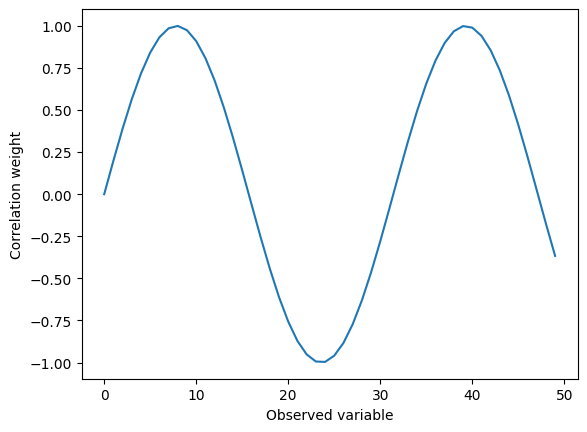

In [13]:
plt.plot(pattern)
plt.xlabel('Observed variable')
plt.ylabel('Correlation weight')

## Fitting and evaluating the model

In [9]:
mod = PLSC(random_state=123)
mod.fit(data=data,
        covariates=covariates)

Permutation testing to evaluate significance of latent variables:

In [10]:
mod.permute(1000)
print(mod.pvals_)
is_sig = mod.pvals_ < 0.05
sig_lvs = np.where(is_sig)[0]
print(sig_lvs)

Permuting: 100%|███████████████████████████████████████████████████████████████████████████████| 1000/1000 [00:02<00:00, 422.69it/s]

[0.001998   0.95404595 0.85114885 0.37462537]
[0]


Thus there is a single significant latent variable, in line with how we simulated the data. Next, we can perform bootstrap resampling to assess the reliability of the saliences and to evaluate how reliably each latent variable correlates with each covariate. We will see shortly how to visualize the results of resampling.

In [11]:
mod.bootstrap(1000)

Resampling: 100%|██████████████████████████████████████████████████████████████████████████████| 1000/1000 [00:04<00:00, 216.96it/s]


## Visualizing the model

Next we will visualize each significant latent variable.

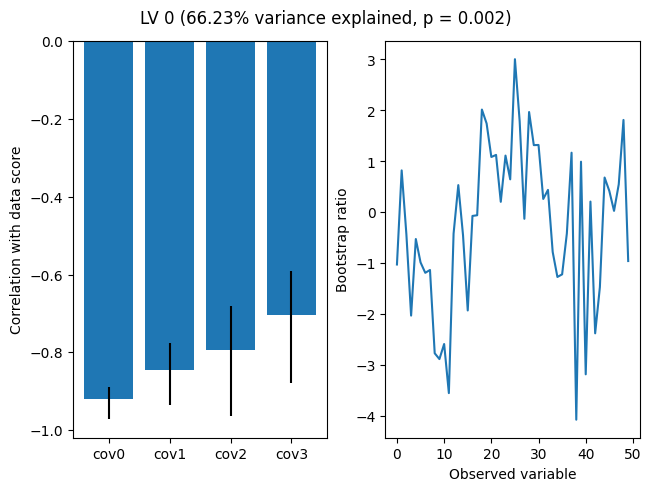

In [14]:
labels = mod.get_labels('covariate')
n_sig = len(sig_lvs)

fig = plt.figure(constrained_layout=True)
subfigs = fig.subfigures(nrows=n_sig)
if n_sig == 1:
    subfigs = [subfigs]

for plot_idx, lv_idx in enumerate(sig_lvs):
    subfig = subfigs[plot_idx]
    subfig.suptitle('LV %s (%.2f%% variance explained, p = %.3f)' % (
        lv_idx,
        100*mod.variance_explained_[lv_idx],
        mod.pvals_[lv_idx]))
    ax = subfig.subplots(ncols=2)
    ax[0].bar(x=labels,
              height=mod.boot_stat_val_[:, lv_idx],
              yerr=mod.get_boot_stat_yerr(lv_idx))
    ax[0].set_ylabel('Correlation with data score')
    ax[1].plot(mod.bootstrap_ratios_[:, lv_idx])
    ax[1].set_ylabel('Bootstrap ratio')
    ax[1].set_xlabel('Observed variable')


As we can see, the boostrap ratios are roughly sinusoidal. `mod.flip_signs(lv_idx=0)` can be used to obtain an equivalent solution in which the covariates have positive correlations with the latent variable.